In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import seaborn as sns

Datasets = []
PREDICTORS = ["PwmD", "PwmE"]   
TARGETS = ["X", "Y", "Theta"]       
# FOLDERS = ["Data", "RotedData"]
FOLDERS = ["RotedData"]

for folder in FOLDERS:
    for i in range(2):   
        Dataset = pd.read_csv(f"../{folder}/Data{i + 1}.csv")
            
        # Ajusta índice pelo tempo
        Dataset.index = (np.arange(0, len(Dataset), 1).astype(float) * 0.07).round(5)
        
        Datasets.append(Dataset)
        
        print(f"++++++++++++++++++++ Dataset {i+1} +++++++++++++++++++++++")
        print(Dataset.head(5))

++++++++++++++++++++ Dataset 1 +++++++++++++++++++++++
        X    Y  Theta    Wd   We  WdRef  WeRef   PwmD   PwmE
0.00  0.0  0.7   0.00  0.00  0.0  -0.00   0.00  -0.00   0.00
0.07  0.0  0.7   0.00  0.00  0.0   3.28   3.28  -0.00   0.00
0.14  0.0  0.7   0.00  0.00  0.0   3.28   3.28  49.25  49.25
0.21  0.0  0.7   0.00  0.06  0.0   3.28   3.28  49.25  49.25
0.28  0.0  0.7   0.01  0.33  0.0   3.28   3.28  68.07  68.91
++++++++++++++++++++ Dataset 2 +++++++++++++++++++++++
        X    Y  Theta    Wd   We  WdRef  WeRef   PwmD   PwmE
0.00  0.0  0.7    0.0  0.00  0.0  -0.00   0.00  -0.00   0.00
0.07  0.0  0.7    0.0  0.00  0.0   3.28   3.28  -0.00   0.00
0.14  0.0  0.7    0.0  0.00  0.0   3.28   3.28  49.25  49.25
0.21  0.0  0.7    0.0  0.14  0.0   3.28   3.28  49.25  49.25
0.28  0.0  0.7    0.0  0.00  0.0   3.27   3.27  66.69  68.80


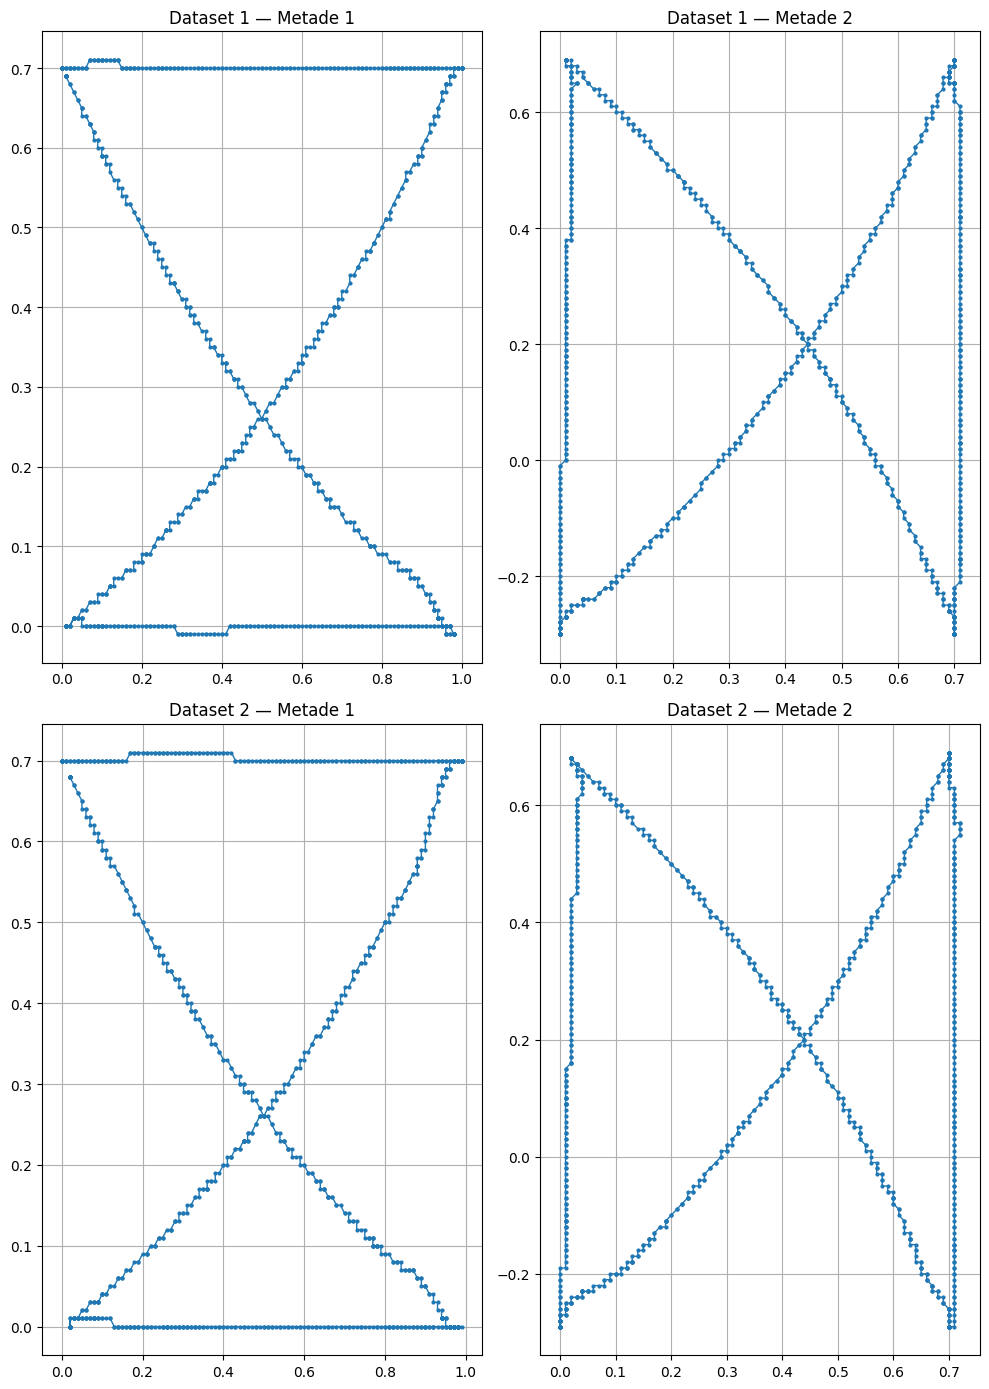

In [2]:
Halves = [(df.iloc[:len(df)//2], df.iloc[len(df)//2:]) for df in Datasets]

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 14))  # 2 datasets × 2 metades
axes = axes.ravel()

i = 0
for k, (first, second) in enumerate(Halves):
    for half_idx, part in enumerate([first, second]):
        ax = axes[i]
        ax.plot(part["X"], part["Y"], marker='o', linewidth=1, markersize=2)
        ax.set_title(f"Dataset {k+1} — Metade {half_idx+1}")
        ax.grid(True)
        i += 1

plt.tight_layout()
plt.show()


In [3]:


OUTPUT_FILE = "Datasets_halves.xlsx"

with pd.ExcelWriter(OUTPUT_FILE) as writer:
    for k, (first, second) in enumerate(Halves, start=1):

        # Primeira metade
        first.to_excel(
            writer,
            sheet_name=f"Dataset{k}_ZZ",
            index=True
        )

        # Segunda metade
        second.to_excel(
            writer,
            sheet_name=f"Dataset{k}_ZZR",
            index=True
        )

print("Exportação em .xlsx concluída.")


Exportação em .xlsx concluída.


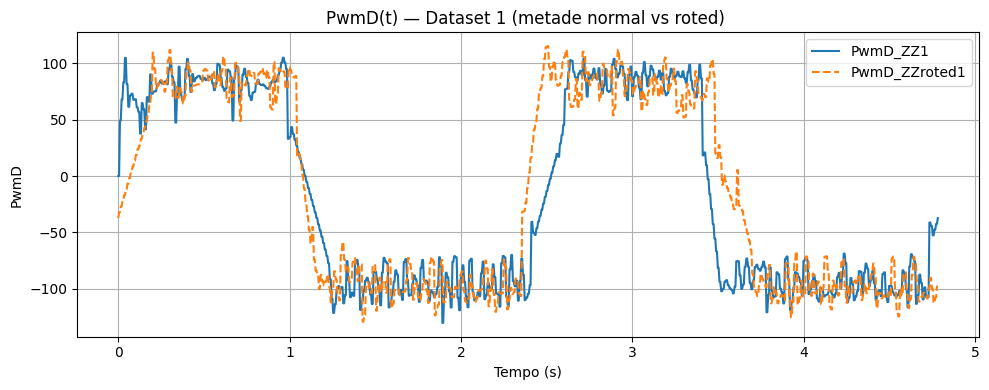

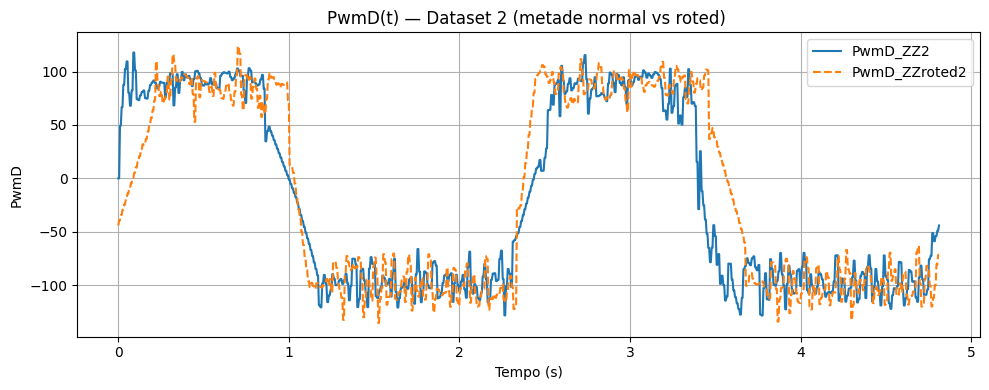

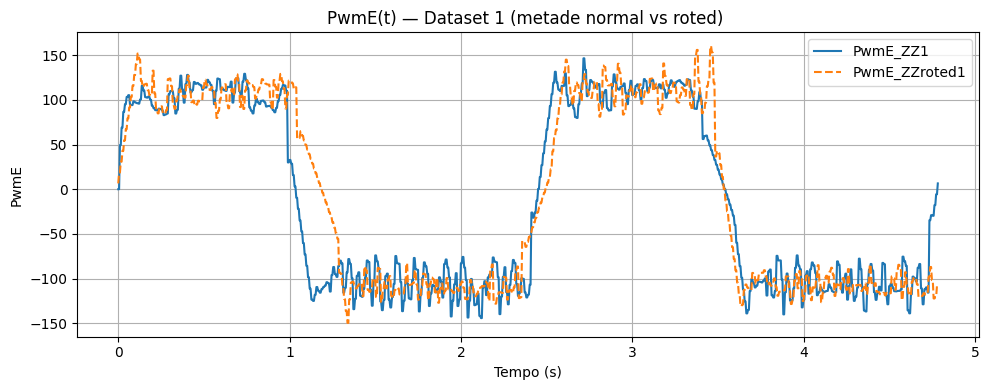

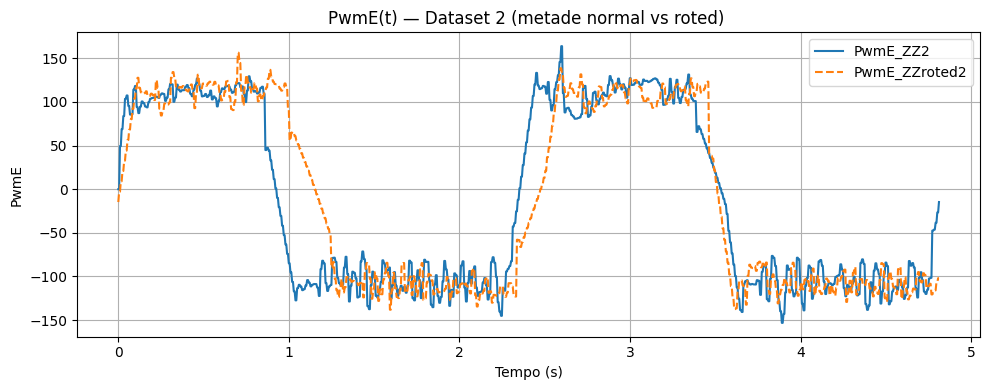

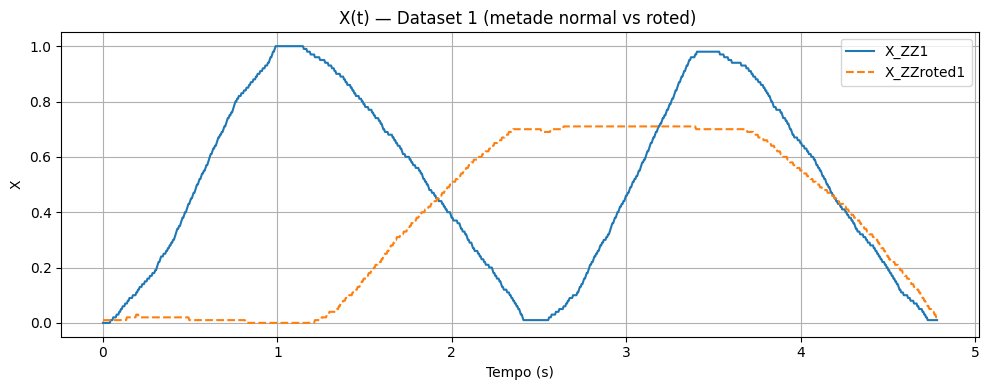

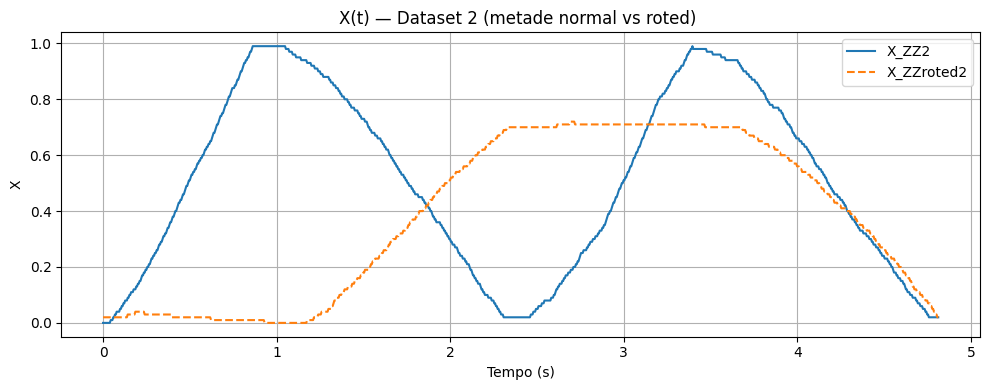

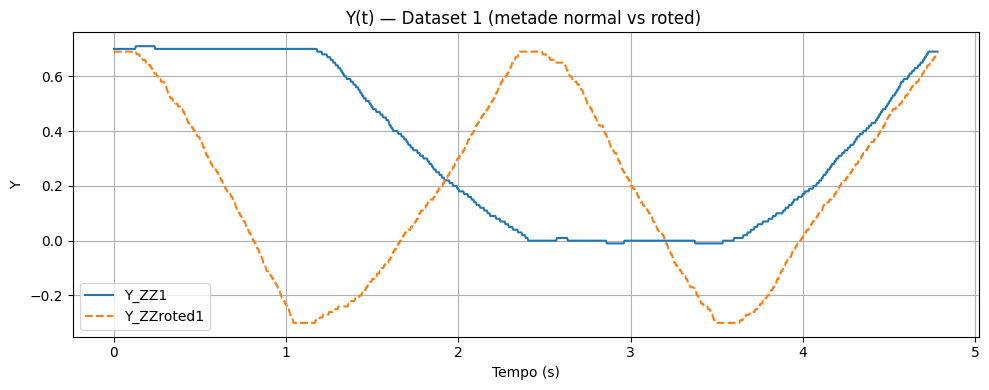

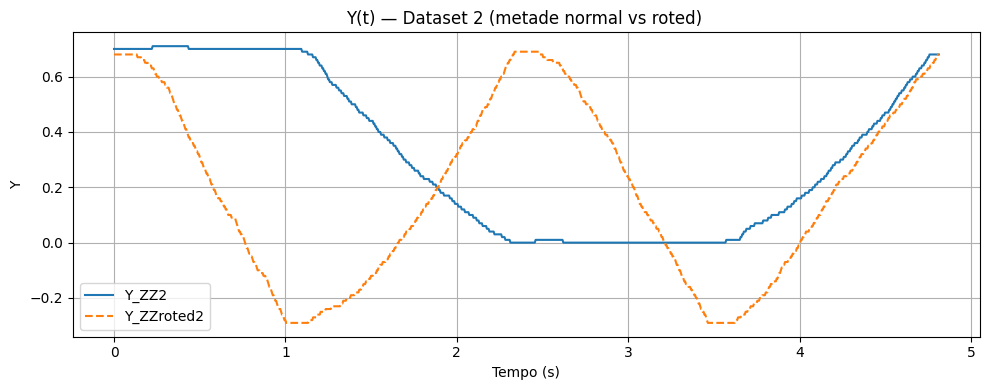

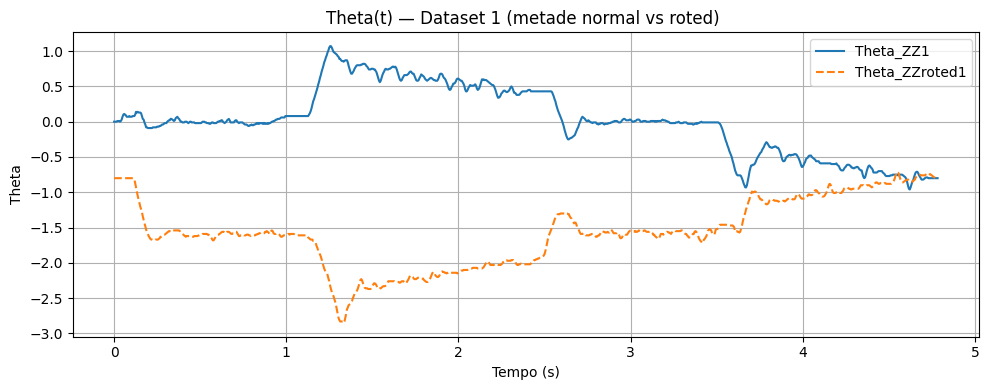

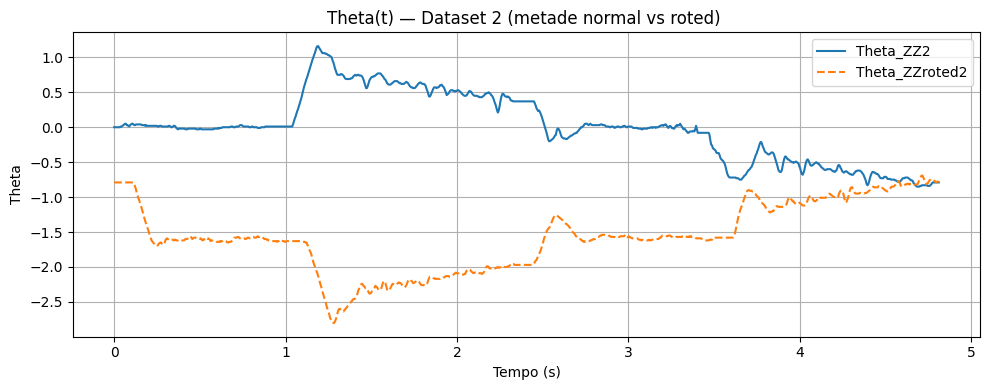

In [4]:
VARS = PREDICTORS + TARGETS
# Já assumimos que Datasets está preenchido e index é tempo absoluto (0,0.07,...)
# 1) dividir em metades (first = normal, second = roted)
Halves = [(df.iloc[:len(df)//2].copy(), df.iloc[len(df)//2:].copy()) for df in Datasets]

# 2) construir DataFrames pareados por time step para cada var e cada dataset
# estrutura: Paired[var] = [ df_paired_dataset1, df_paired_dataset2, ... ]
Paired = {var: [] for var in VARS}
dt = 0.07

for k, (first, second) in enumerate(Halves):
    # comprimento de cada metade (assumimos iguais)
    L = len(first)
    t_half = (np.arange(0, L) * dt).round(5)

    for var in VARS:
        # garantir que ambos têm tamanho L
        a = first[var].reset_index(drop=True).iloc[:L]   # var normal
        b = second[var].reset_index(drop=True).iloc[:L]  # var roted

        paired_df = pd.DataFrame({
            f"{var}_ZZ": a.values,
            f"{var}_ZZroted": b.values
        }, index=t_half)

        paired_df.index.name = "t (s)"
        Paired[var].append(paired_df)

for var in VARS:
    for k, paired_df in enumerate(Paired[var], start=1):
        plt.figure(figsize=(10,4))
        plt.plot(paired_df.index * 0.07, paired_df[f"{var}_ZZ"], label=f"{var}_ZZ{k}")
        plt.plot(paired_df.index * 0.07, paired_df[f"{var}_ZZroted"], '--', label=f"{var}_ZZroted{k}")
        plt.title(f"{var}(t) — Dataset {k} (metade normal vs roted) ")
        plt.xlabel("Tempo (s)")
        plt.ylabel(var)
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [5]:
Paired

{'PwmD': [       PwmD_ZZ  PwmD_ZZroted
  t (s)                       
  0.00     -0.00        -37.37
  0.07     -0.00        -32.28
  0.14     49.25        -32.28
  0.21     49.25        -27.18
  0.28     68.07        -27.18
  ...        ...           ...
  68.04   -47.56       -112.80
  68.11   -47.56       -107.79
  68.18   -42.47       -107.79
  68.25   -42.47        -98.04
  68.32   -37.37        -98.04
  
  [977 rows x 2 columns],
         PwmD_ZZ  PwmD_ZZroted
  t (s)                       
  0.00     -0.00        -44.07
  0.07     -0.00        -39.15
  0.14     49.25        -39.15
  0.21     49.25        -34.24
  0.28     66.69        -34.24
  ...        ...           ...
  68.46   -53.90       -100.01
  68.53   -53.90        -80.69
  68.60   -48.98        -80.69
  68.67   -48.98        -71.69
  68.74   -44.07        -71.69
  
  [983 rows x 2 columns]],
 'PwmE': [       PwmE_ZZ  PwmE_ZZroted
  t (s)                       
  0.00      0.00          6.50
  0.07      0.00         1